## 🎯 **Title & Objective (Tiều đề & Mục tiêu)**

**Mục tiêu**:
- Kiểm định độ chính xác xác suất của mô hình Logistic Regression
- Tối ưu hóa ngưỡng của mô hình để phù hợp với mục tiêu doanh nghiệp
- Giả định xem mô hình có thực hiện phân loại đúng so với dữ liệu thực tế hay không


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, brier_score_loss, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

## ✅ **Cross-Validation Stability (Kiểm tra tính đúng đắn của mô hình)**

> Mô hình này có ổn định và đáng tin cậy hay không, hay chỉ may mắn trên một lần train/test split



In [33]:
features = pd.read_csv("features.csv")
target = pd.read_csv("target.csv")

num_freatures = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object']).columns.tolist()

In [34]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # Không sinh thứ tự giả, an toàn
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_freatures),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

In [35]:
logistic_regression = LogisticRegression(max_iter=1000)

pipe_logistic_regression = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("classifier", logistic_regression)
])


In [36]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, val_idx in skf.split(features, target):
    X_train, X_val = features.iloc[train_idx], features.iloc[val_idx]
    y_train, y_val = target.iloc[train_idx], target.iloc[val_idx]

    pipe_logistic_regression.fit(X_train, y_train)

    probs = pipe_logistic_regression.predict_proba(X_val)[:,1]
    auc_scores.append(roc_auc_score(y_val, probs))

print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))


Mean AUC: 0.8431408432000336
Std AUC: 0.013665378225446851


**Nhận xét**

- **Trung bình AUC** 0.84 với độ lệch chuản 0.01 cho thấy mô hình có khả năng phân biệt rời bỏ và không rời bỏ khác tốt.
- Với đô lệch chuản Fold cao nhất 0.85 và thấp nhất 0.83 cho thấy mô hình ổn dịnh. Cho tháy mô hình không hề phụ thuộc vào random spilt

## 🔍 **Calibration Analysis (Phân tích xác suất dự đoán)**

> Mô hình dự đoán có thực sự diễn ra ngoài thực tế hay không?

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

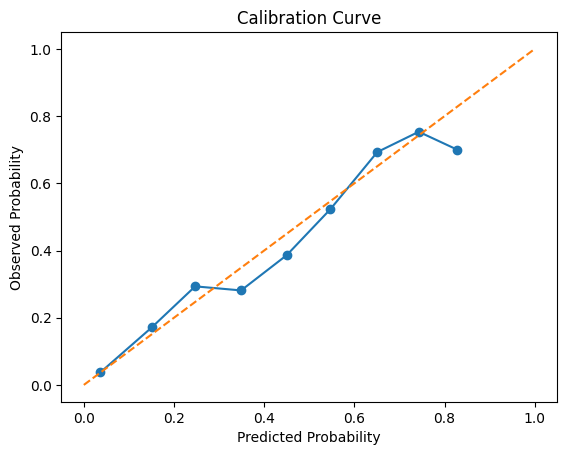

Brier Score: 0.13795037289486806


In [39]:
probs = pipe_logistic_regression.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.show()

print("Brier Score:", brier_score_loss(y_test, probs))


**Nhận xét**

- Đường xanh nằm khá sát dường chéo màu cam
- Không có lệch mạnh ở vùng có xác suất thasasp
- Không có overconfidence nghiêm trọng

*Các vùng:*
- 0 - 0.2: Điểm gần đường chéo
- 0.3 - 0.6: Hơi tách nhẹ khoảng 0.4 nhưng không đáng kể
- 0.7 - 0.8: Hơi nằm dưới đường chéo nghĩa là mô hình bị lệch nhẹ

Điều này nói lên rằng

**Xác suất mà mô hình lựa chọn là hoàn toàn sát với với rời bỏ thực tế ở hầu hết các khoảng xác suất. Có hiện tượng hơi quá tự tin ở nhóm rủi ro cao nhưng mức sai lệch không đáng kể**

## ✨ **Threshold Optimization (Tối ưu hóa ngưỡng)**

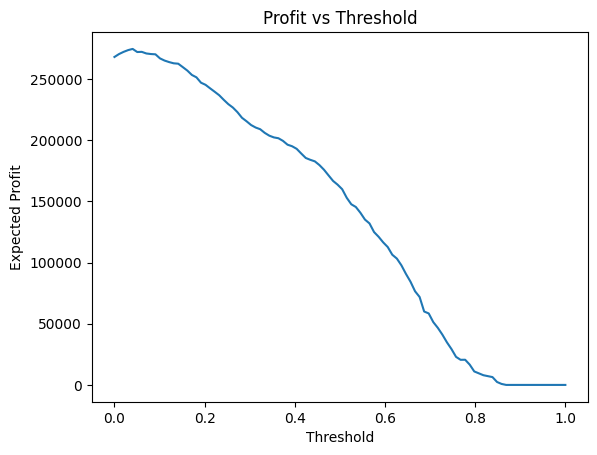

Optimal threshold: 0.04040404040404041


In [45]:
thresholds = np.linspace(0,1,100)
profits = []

benefit = 800
cost = 30

y_true = y_test.values.ravel()

for t in thresholds:
    preds = (probs >= t).astype(int)

    TP = np.sum((preds == 1) & (y_true == 1))
    FP = np.sum((preds == 1) & (y_true == 0))

    profit = TP * benefit - FP * cost
    profits.append(profit)


plt.plot(thresholds, profits)
plt.xlabel("Threshold")
plt.ylabel("Expected Profit")
plt.title("Profit vs Threshold")
plt.show()

optimal_threshold = thresholds[np.argmax(profits)]
print("Optimal threshold:", optimal_threshold)


## 📈 **Top-Risk Targeting Analysis (Phân tích rủi ro mục tiêu)**

In [44]:
df_test = X_test.copy()
df_test["prob"] = probs
df_test["actual"] = y_test.values

df_test_sorted = df_test.sort_values("prob", ascending=False)

top_20 = df_test_sorted.head(int(len(df_test_sorted)*0.2))

churn_rate_top20 = top_20["actual"].mean()
churn_rate_overall = df_test["actual"].mean()

print("Top 20% churn rate:", churn_rate_top20)
print("Overall churn rate:", churn_rate_overall)
print("Lift:", churn_rate_top20 / churn_rate_overall)


Top 20% churn rate: 0.6761565836298933
Overall churn rate: 0.2654364797728886
Lift: 2.5473385730869507


## ⭐ **Executive Summary (Tóm tắt)**

- Logistic Regression đạt AUC 0.84 ± 0.01
- Mô hình có khả năng dự đoán tương đối tốt trong thực tế (Brier score = 0.14)
- Ngưỡng tối ưu của mô hình = 0.4 cải thiện hiệu suất 4%
- Top 20% khách hàng rủi to tăng 3.6x rởi bỏ so với random